In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

In [2]:
## Import Dataset
data = pd.read_csv("Mobile.csv")

In [3]:
data

,Battery_power_mAh,Bluetooh,Speed_of_microprocessor,Dual_sim,Front_camera,4G,Internal_memeory_gb,Mobile_depth,Mobile_weight,Cores_of_processor,...,px_height,Pixel_width,Ram_mb,Screen_height,Screen_weight,talk_time,3G,touch_screen,wifi,price_range
0,842 mAh,No,2.2,No,1 pixels,No,7 gb,0.6 cm,188 g,2,...,20 ppcm,756 ppcm,2549 mb,9 cm,7 cm,19,No,No,Yes,Medium cost
1,1021 mAh,Yes,0.5,Yes,0 pixels,Yes,53 gb,0.7 cm,136 g,3,...,905 ppcm,1988 ppcm,2631 mb,17 cm,3 cm,7,Yes,Yes,No,High cost
2,563 mAh,Yes,0.5,Yes,2 pixels,Yes,41 gb,0.9 cm,145 g,5,...,1263 ppcm,1716 ppcm,2603 mb,11 cm,2 cm,9,Yes,Yes,No,High cost
3,615 mAh,Yes,2.5,No,0 pixels,No,10 gb,0.8 cm,131 g,6,...,1216 ppcm,1786 ppcm,2769 mb,16 cm,8 cm,11,Yes,No,No,High cost
4,1821 mAh,Yes,1.2,No,13 pixels,Yes,44 gb,0.6 cm,141 g,2,...,1208 ppcm,1212 ppcm,1411 mb,8 cm,2 cm,15,Yes,Yes,No,Medium cost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794 mAh,Yes,0.5,Yes,0 pixels,Yes,2 gb,0.8 cm,106 g,6,...,1222 ppcm,1890 ppcm,668 mb,13 cm,4 cm,19,Yes,Yes,No,Low cost
1996,1965 mAh,Yes,2.6,Yes,0 pixels,No,39 gb,0.2 cm,187 g,4,...,915 ppcm,1965 ppcm,2032 mb,11 cm,10 cm,16,Yes,Yes,Yes,High cost
1997,1911 mAh,No,0.9,Yes,1 pixels,Yes,36 gb,0.7 cm,108 g,8,...,868 ppcm,1632 ppcm,3057 mb,9 cm,1 cm,5,Yes,Yes,No,Very High cost
1998,1512 mAh,No,0.9,No,4 pixels,Yes,46 gb,0.1 cm,145 g,5,...,336 ppcm,670 ppcm,869 mb,18 cm,10 cm,19,Yes,Yes,Yes,Low cost


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Battery_power_mAh        2000 non-null   str    
 1   Bluetooh                 2000 non-null   str    
 2   Speed_of_microprocessor  2000 non-null   float64
 3   Dual_sim                 2000 non-null   str    
 4   Front_camera             2000 non-null   str    
 5   4G                       2000 non-null   str    
 6   Internal_memeory_gb      2000 non-null   str    
 7   Mobile_depth             2000 non-null   str    
 8   Mobile_weight            2000 non-null   str    
 9   Cores_of_processor       2000 non-null   int64  
 10  Primary_camera           2000 non-null   str    
 11  px_height                2000 non-null   str    
 12  Pixel_width              2000 non-null   str    
 13  Ram_mb                   2000 non-null   str    
 14  Screen_height            2000 non-n

In [5]:
data.describe()

,Speed_of_microprocessor,Cores_of_processor,talk_time
count,2000.000000,2000.000000,2000.000000
mean,1.522250,4.520500,11.011000
std,0.816004,2.287837,5.463955
min,0.500000,1.000000,2.000000
25%,0.700000,3.000000,6.000000
50%,1.500000,4.000000,11.000000
75%,2.200000,7.000000,16.000000
max,3.000000,8.000000,20.000000


In [6]:
## replace units with space and convert it into float
def replace_with_space(col, rep):
    data[col] = data[col].str.replace(rep ," ", regex=False).str.strip().astype(float)

In [7]:
## Dictionary of column name with units
col_dict = {
    "Battery_power_mAh": "mAh",
    "Front_camera": "pixels",
    "Internal_memeory_gb": "gb",
    "Mobile_depth": "cm",
    "Mobile_weight": "g",
    "Primary_camera": "pixels",
    "px_height": "ppcm",
    "Pixel_width": "ppcm",
    "Ram_mb": "mb",
    "Screen_height": "cm",
    "Screen_weight": "cm"
}

In [8]:
for col, repl in col_dict.items():
    replace_with_space(col, repl)

In [9]:
data.head()

,Battery_power_mAh,Bluetooh,Speed_of_microprocessor,Dual_sim,Front_camera,4G,Internal_memeory_gb,Mobile_depth,Mobile_weight,Cores_of_processor,...,px_height,Pixel_width,Ram_mb,Screen_height,Screen_weight,talk_time,3G,touch_screen,wifi,price_range
0,842.0,No,2.2,No,1.0,No,7.0,0.6,188.0,2,...,20.0,756.0,2549.0,9.0,7.0,19,No,No,Yes,Medium cost
1,1021.0,Yes,0.5,Yes,0.0,Yes,53.0,0.7,136.0,3,...,905.0,1988.0,2631.0,17.0,3.0,7,Yes,Yes,No,High cost
2,563.0,Yes,0.5,Yes,2.0,Yes,41.0,0.9,145.0,5,...,1263.0,1716.0,2603.0,11.0,2.0,9,Yes,Yes,No,High cost
3,615.0,Yes,2.5,No,0.0,No,10.0,0.8,131.0,6,...,1216.0,1786.0,2769.0,16.0,8.0,11,Yes,No,No,High cost
4,1821.0,Yes,1.2,No,13.0,Yes,44.0,0.6,141.0,2,...,1208.0,1212.0,1411.0,8.0,2.0,15,Yes,Yes,No,Medium cost


In [10]:
data['price_range'] = data['price_range'].str.replace("cost" ," ", regex=False)

In [11]:
data

,Battery_power_mAh,Bluetooh,Speed_of_microprocessor,Dual_sim,Front_camera,4G,Internal_memeory_gb,Mobile_depth,Mobile_weight,Cores_of_processor,...,px_height,Pixel_width,Ram_mb,Screen_height,Screen_weight,talk_time,3G,touch_screen,wifi,price_range
0,842.0,No,2.2,No,1.0,No,7.0,0.6,188.0,2,...,20.0,756.0,2549.0,9.0,7.0,19,No,No,Yes,Medium
1,1021.0,Yes,0.5,Yes,0.0,Yes,53.0,0.7,136.0,3,...,905.0,1988.0,2631.0,17.0,3.0,7,Yes,Yes,No,High
2,563.0,Yes,0.5,Yes,2.0,Yes,41.0,0.9,145.0,5,...,1263.0,1716.0,2603.0,11.0,2.0,9,Yes,Yes,No,High
3,615.0,Yes,2.5,No,0.0,No,10.0,0.8,131.0,6,...,1216.0,1786.0,2769.0,16.0,8.0,11,Yes,No,No,High
4,1821.0,Yes,1.2,No,13.0,Yes,44.0,0.6,141.0,2,...,1208.0,1212.0,1411.0,8.0,2.0,15,Yes,Yes,No,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794.0,Yes,0.5,Yes,0.0,Yes,2.0,0.8,106.0,6,...,1222.0,1890.0,668.0,13.0,4.0,19,Yes,Yes,No,Low
1996,1965.0,Yes,2.6,Yes,0.0,No,39.0,0.2,187.0,4,...,915.0,1965.0,2032.0,11.0,10.0,16,Yes,Yes,Yes,High
1997,1911.0,No,0.9,Yes,1.0,Yes,36.0,0.7,108.0,8,...,868.0,1632.0,3057.0,9.0,1.0,5,Yes,Yes,No,Very High
1998,1512.0,No,0.9,No,4.0,Yes,46.0,0.1,145.0,5,...,336.0,670.0,869.0,18.0,10.0,19,Yes,Yes,Yes,Low


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

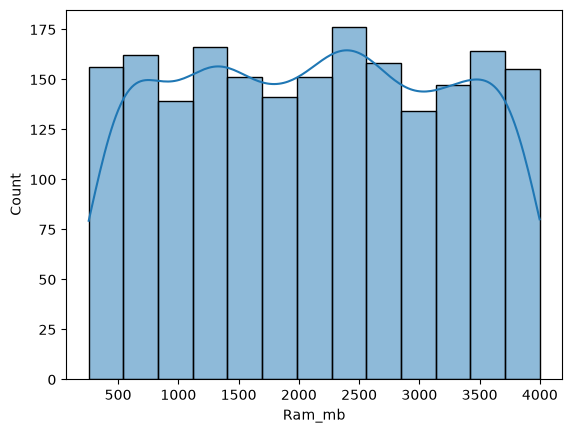

In [13]:
sns.histplot(data=data, x='Ram_mb', kde=True)
plt.show()

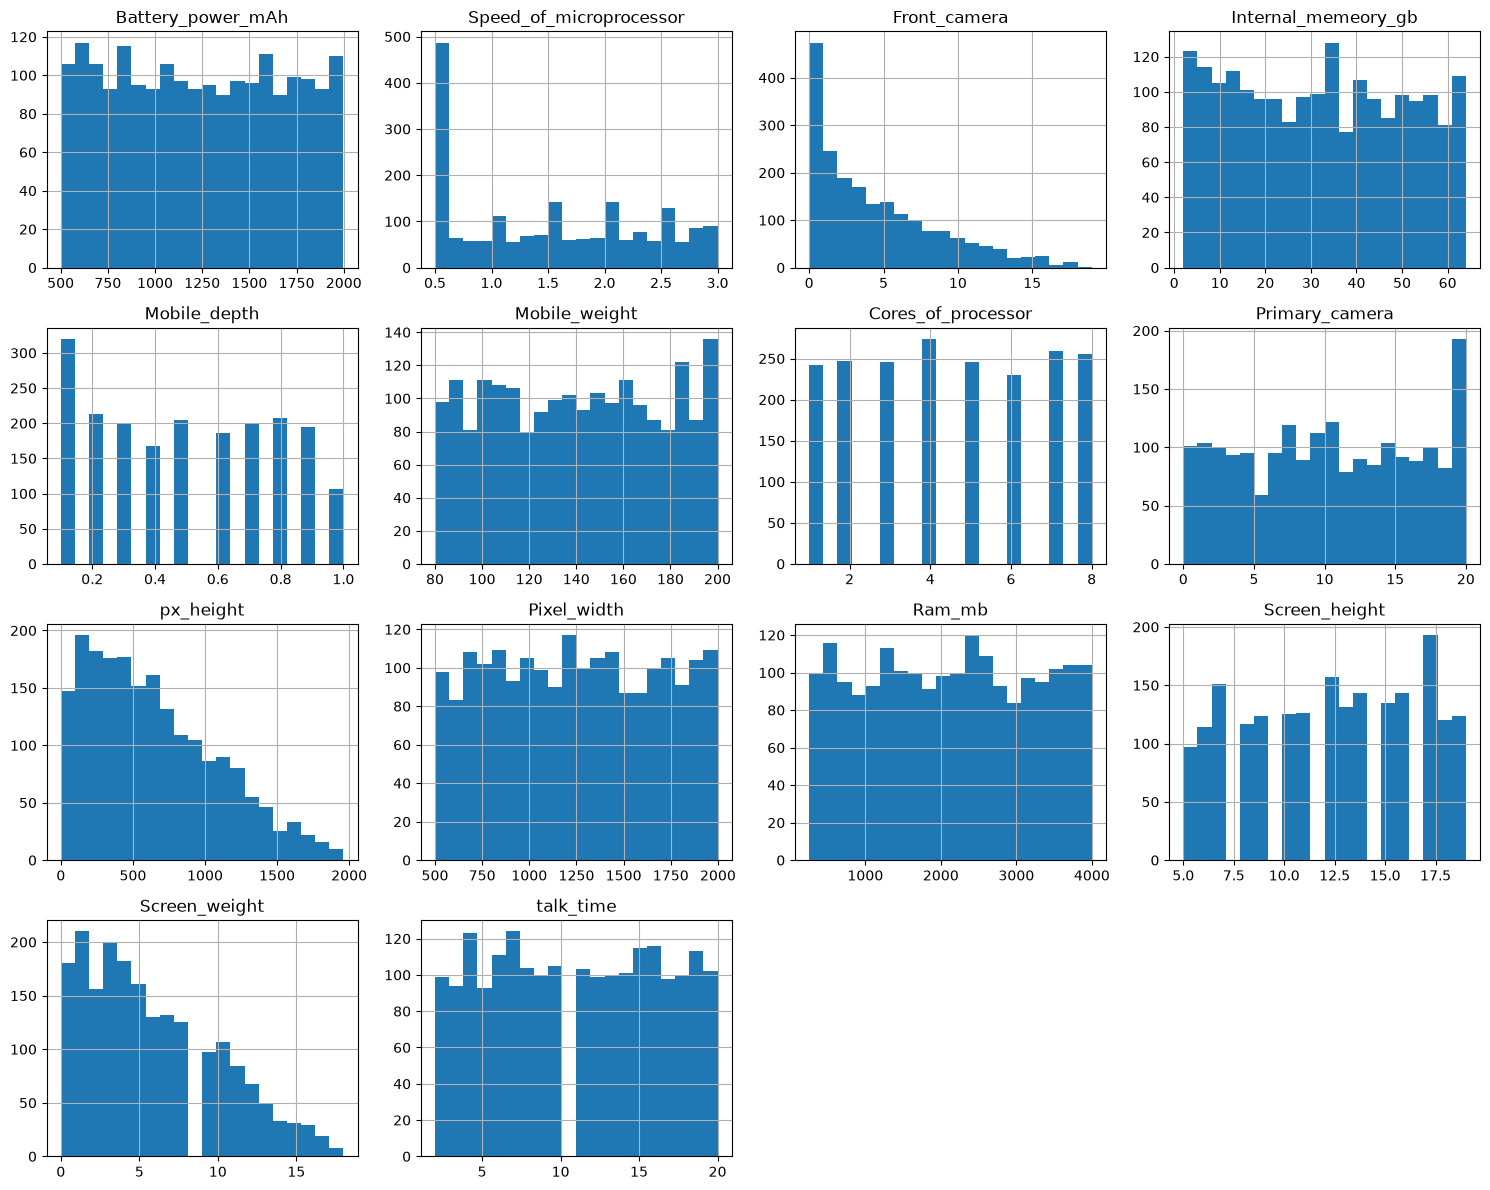

In [14]:
import matplotlib.pyplot as plt

num_cols = data.select_dtypes(include='number').columns

data[num_cols].hist(
    figsize=(15, 12),
    bins=20
)

plt.tight_layout()
plt.show()

In [15]:
## Battery_power_mAh -> uniform distributed 
## Speed_of_microprocessor -> irregular values 
## Front_camera -> right skewed
## Internal_memeory -> uniform distributed 
## Mobile _depth -> irregular values 
## Mobile _weight -> uniform distributed 
## Cores_of_processor -> irregular
## Primary_camera -> uniform 
## px_height -> right skewed
## Pixel_width -> uniform distributed 
## Ram_mb -> uniform distributed 
## Screen_height -> irregular 
## Screen_weight -> right skewed
## talk_time -> uniform distributed 


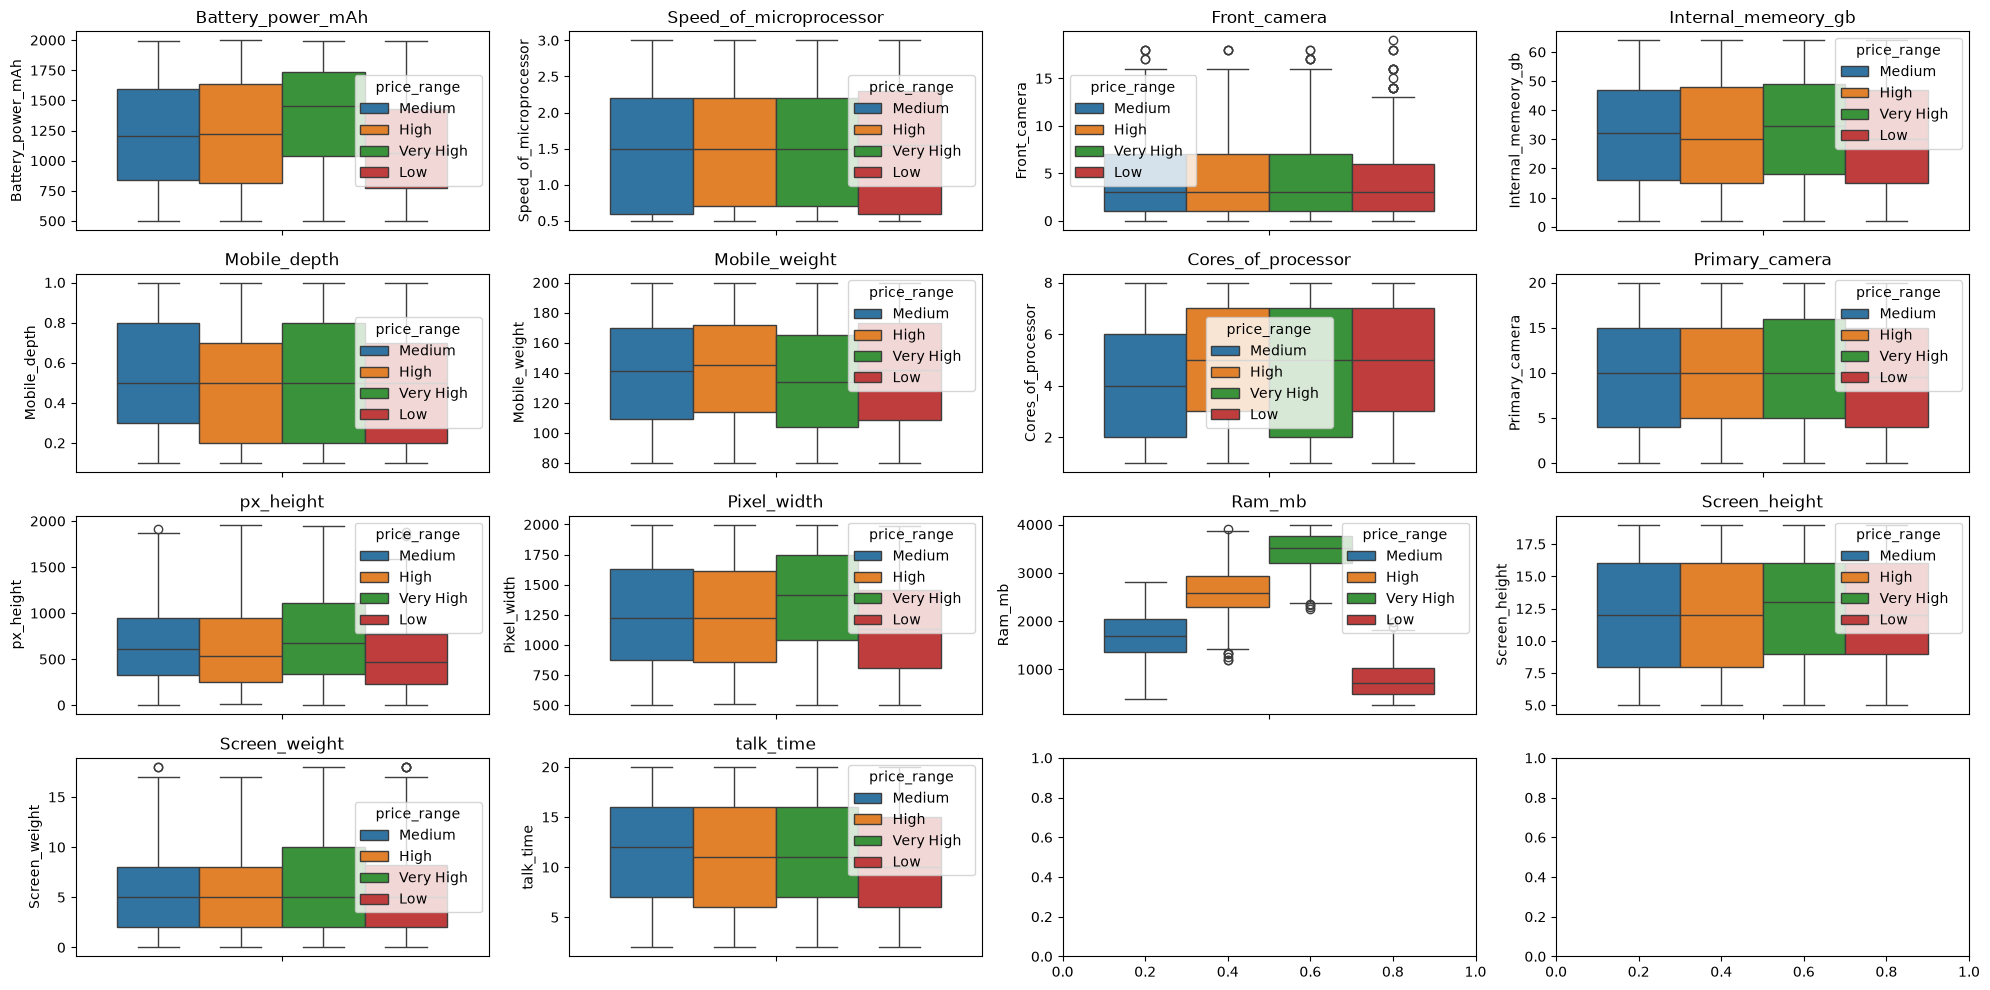

In [16]:
cols = data.select_dtypes(include='number').columns

fig, axes = plt.subplots(4, 4, figsize=(20, 10))

for ax, col in zip(axes.flat, cols):
    sns.boxplot(data=data, y=col, ax=ax, hue="price_range")
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [17]:
## Front_camera and px_height has an outliers 

C:\Users\hp\AppData\Local\Temp\ipykernel_26120\2081058393.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = data.select_dtypes(include='object').columns


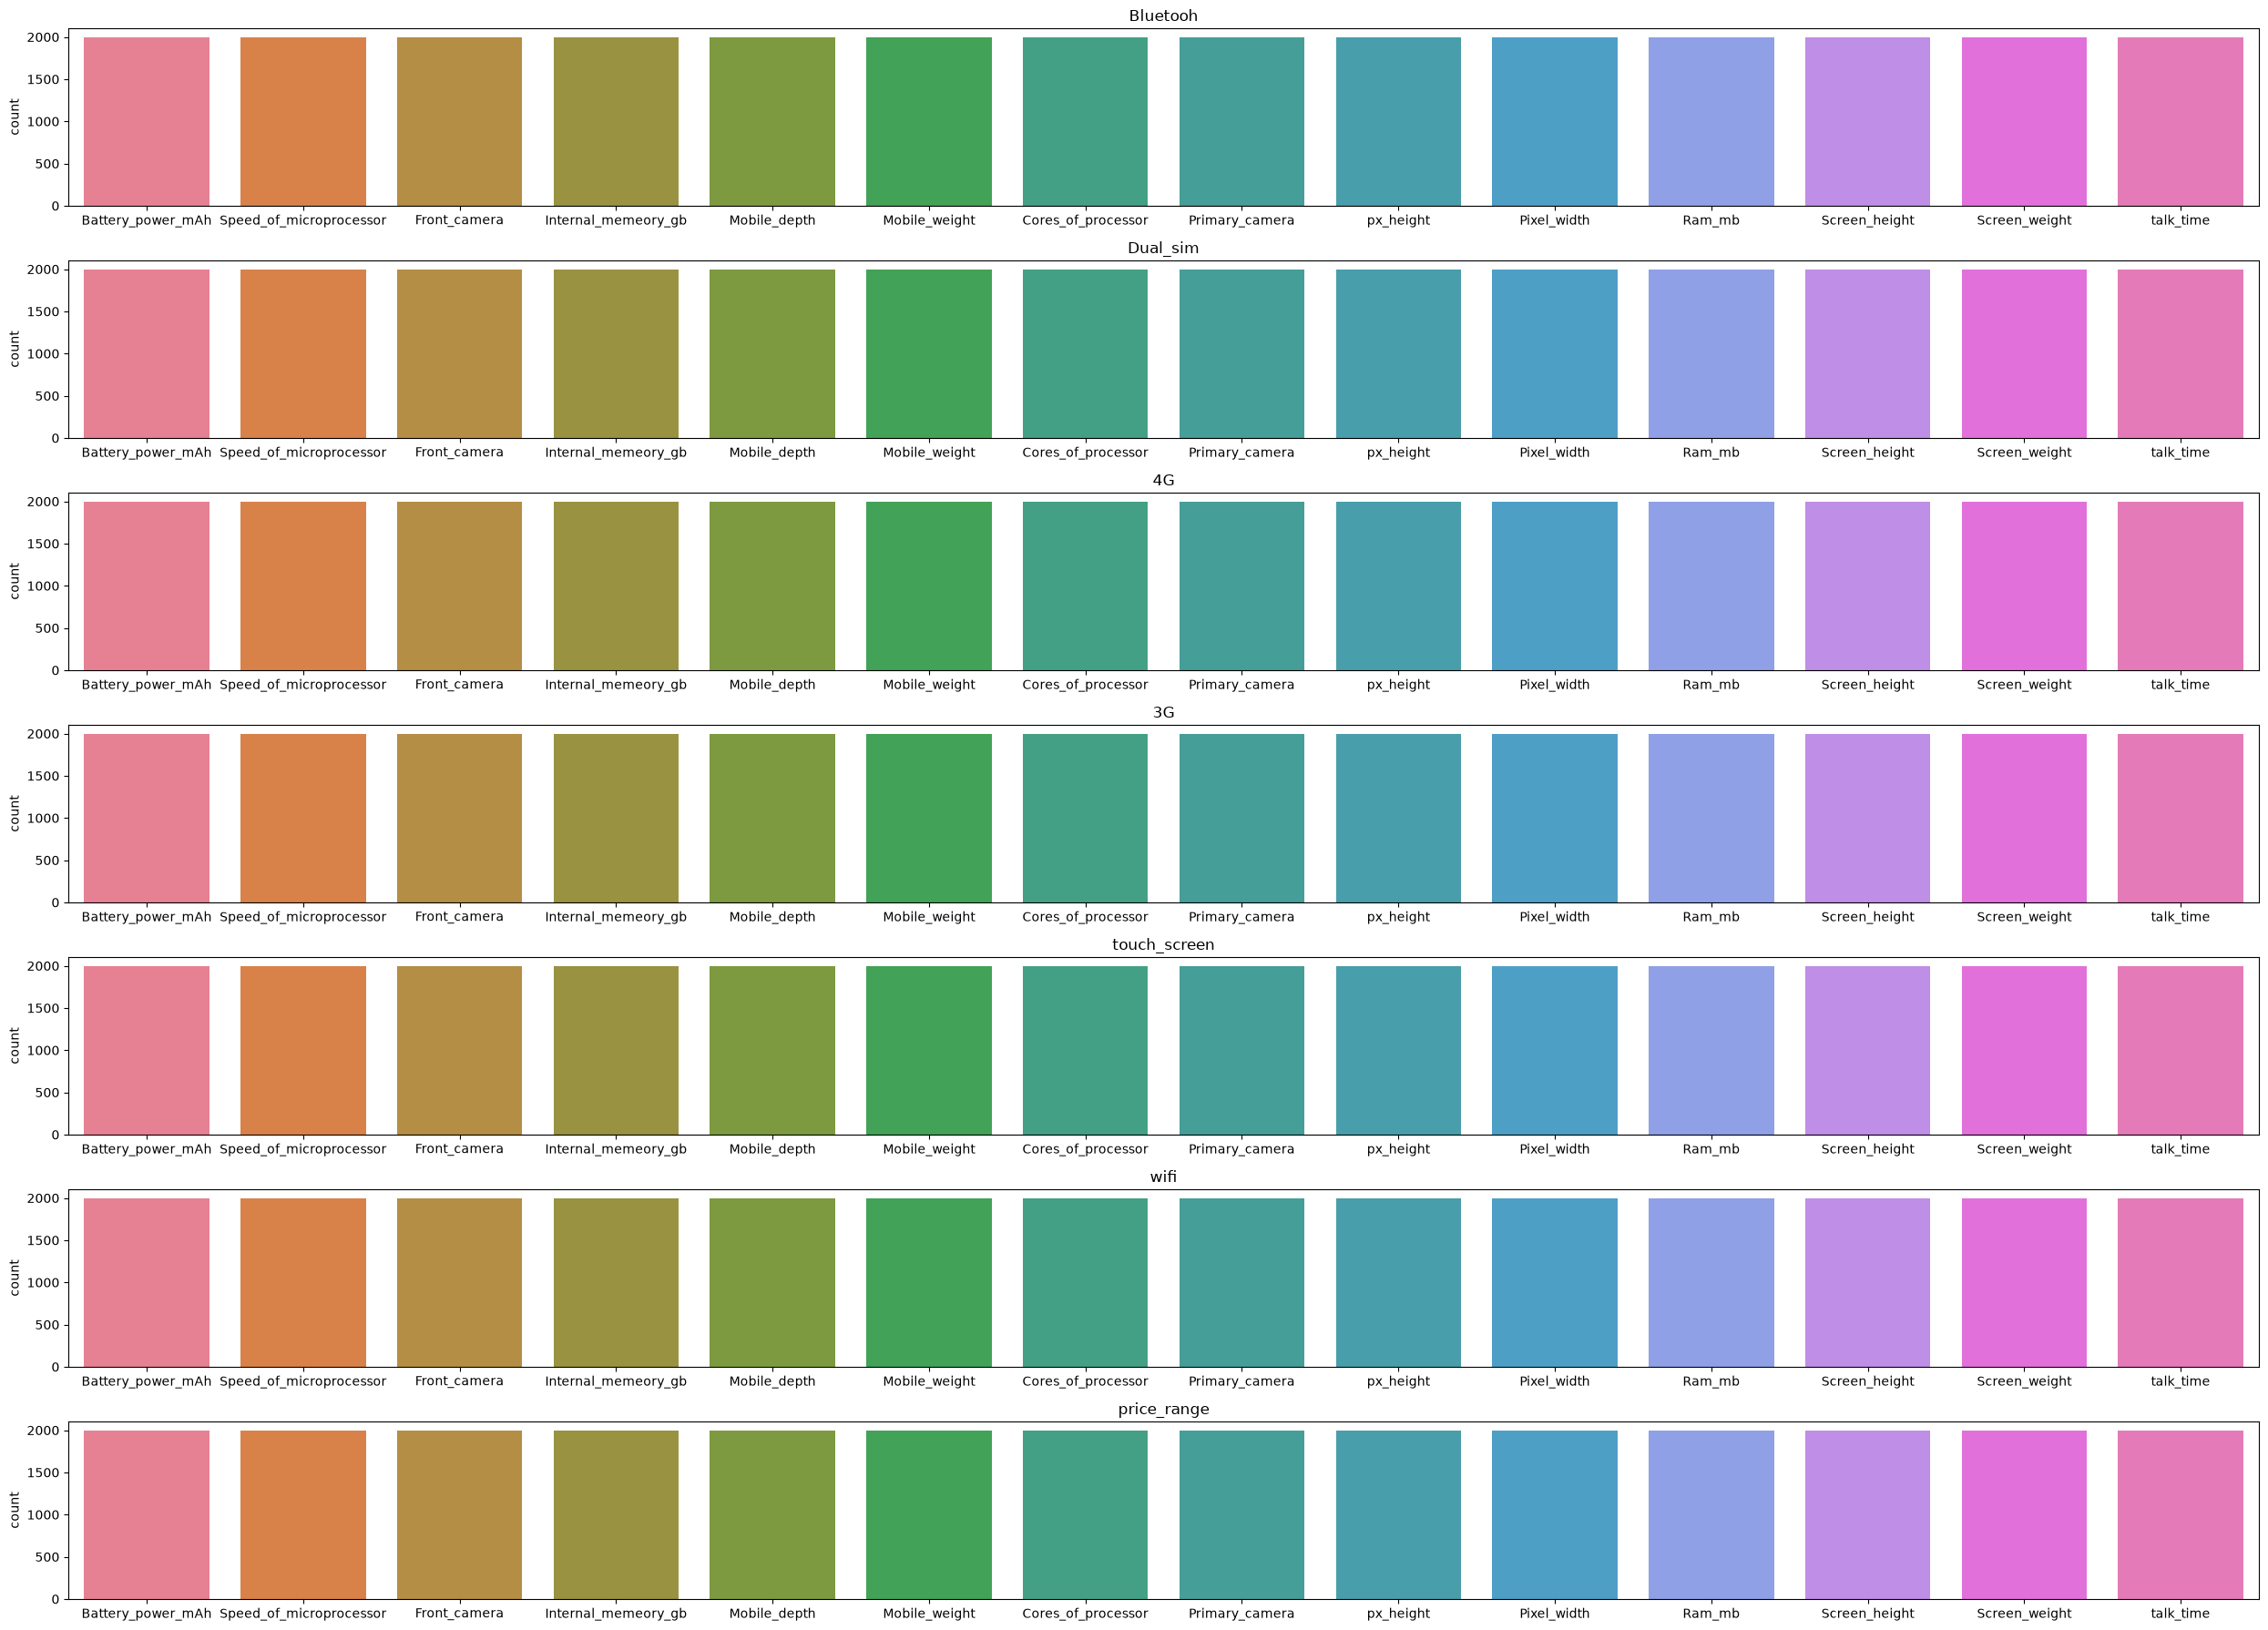

In [26]:
cols = data.select_dtypes(include='object').columns

fig, axes = plt.subplots(7,1, figsize=(25,18))

for ax, col in zip(axes.flat, cols):
    sns.countplot(data=data, ax=ax)
    ax.set_title(col)
    
plt.tight_layout()
plt.show()

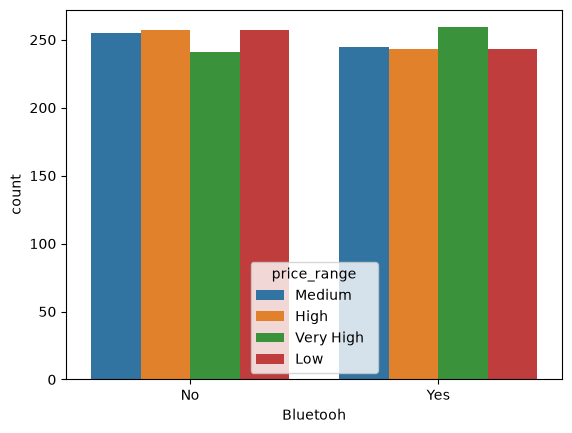

In [28]:
sns.countplot(data=data, x='Bluetooh', hue='price_range')
plt.show()

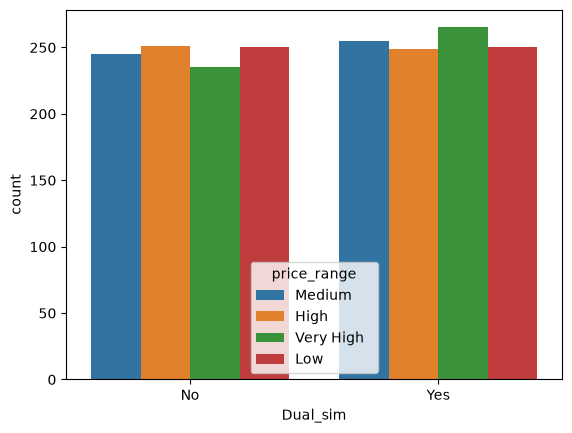

In [29]:
sns.countplot(data=data, x='Dual_sim', hue='price_range')
plt.show()

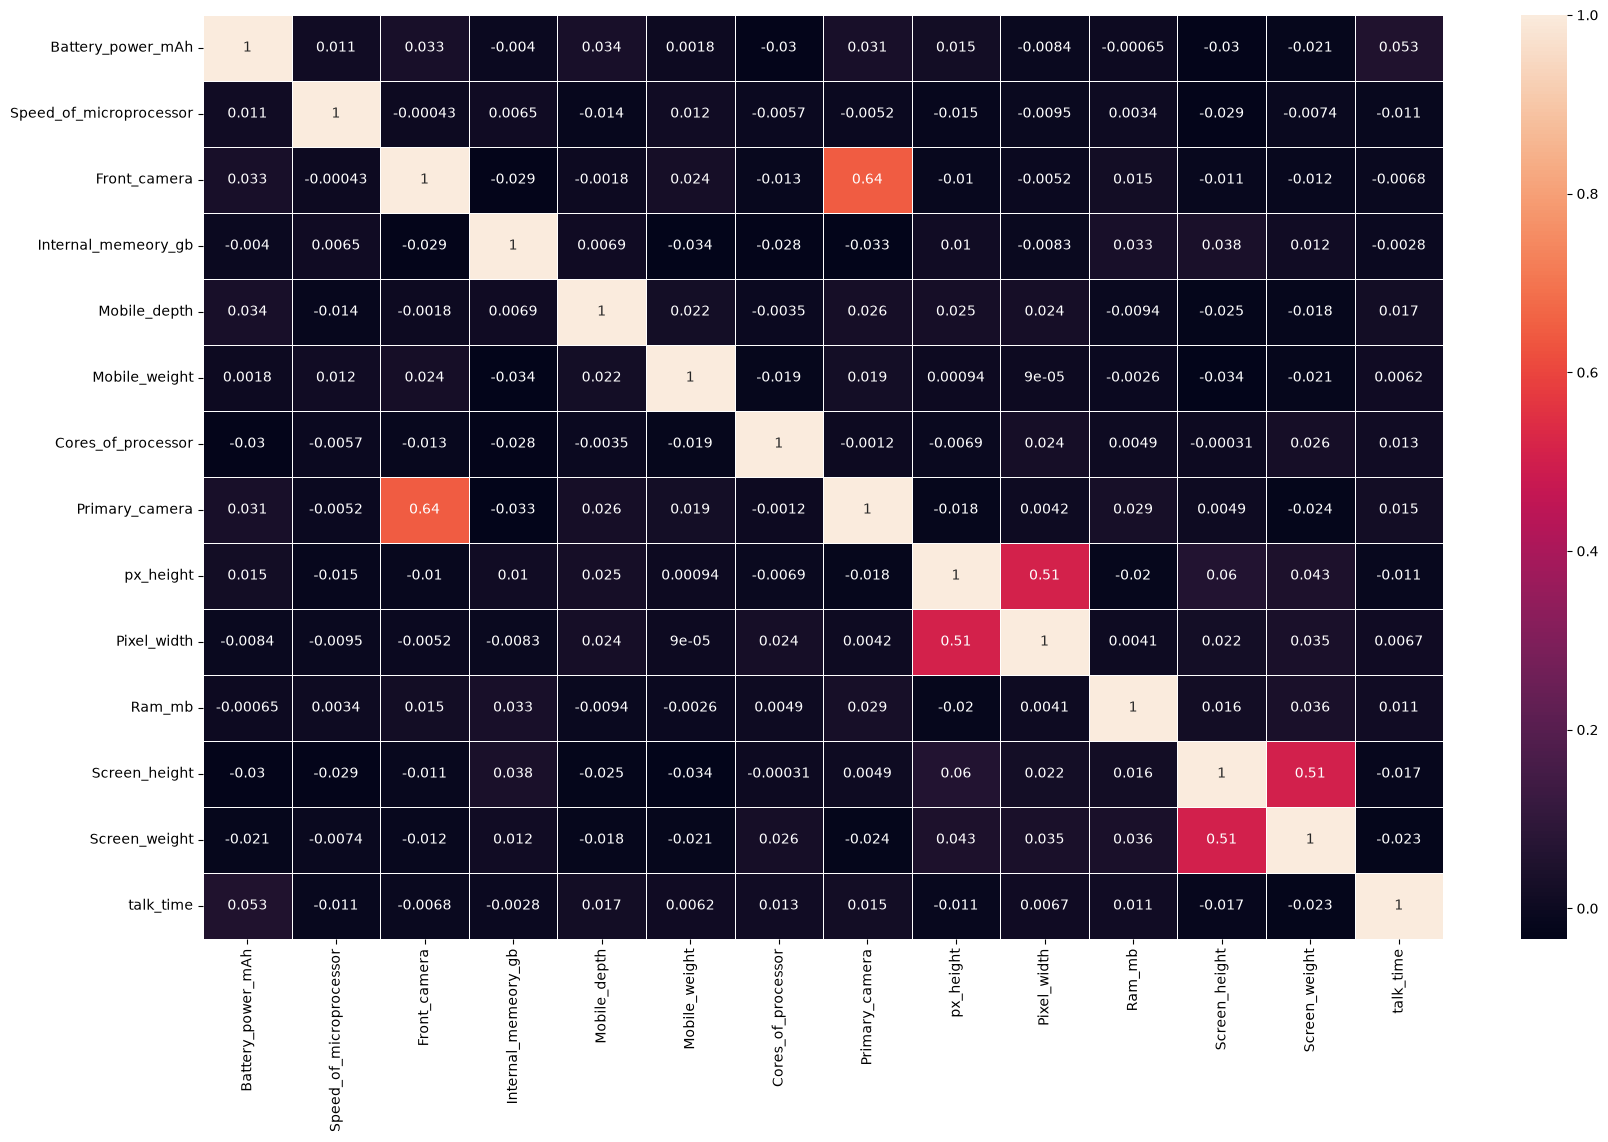

In [30]:
plt.figure(figsize=(20,12))
sns.heatmap(data.corr(numeric_only=True),annot=True, linewidth=.5)
plt.show()

In [31]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Battery_power_mAh        2000 non-null   float64
 1   Bluetooh                 2000 non-null   str    
 2   Speed_of_microprocessor  2000 non-null   float64
 3   Dual_sim                 2000 non-null   str    
 4   Front_camera             2000 non-null   float64
 5   4G                       2000 non-null   str    
 6   Internal_memeory_gb      2000 non-null   float64
 7   Mobile_depth             2000 non-null   float64
 8   Mobile_weight            2000 non-null   float64
 9   Cores_of_processor       2000 non-null   int64  
 10  Primary_camera           2000 non-null   float64
 11  px_height                2000 non-null   float64
 12  Pixel_width              2000 non-null   float64
 13  Ram_mb                   2000 non-null   float64
 14  Screen_height            2000 non-n

In [32]:
data.columns

Index(['Battery_power_mAh', 'Bluetooh', 'Speed_of_microprocessor', 'Dual_sim',
       'Front_camera', '4G', 'Internal_memeory_gb', 'Mobile_depth',
       'Mobile_weight', 'Cores_of_processor', 'Primary_camera', 'px_height',
       'Pixel_width', 'Ram_mb', 'Screen_height', 'Screen_weight', 'talk_time',
       '3G', 'touch_screen', 'wifi', 'price_range'],
      dtype='str')

In [33]:
## Convert yes/no columns with 1 and 0 using replace method
binary_col = ['Bluetooh', 'Dual_sim', '4G', '3G', 'touch_screen', 'wifi']
data[binary_col] = data[binary_col].replace({"Yes":1, "No":0})

In [34]:
## change columns that contains string into integer

In [35]:
data[['Bluetooh', 'Dual_sim', '4G', '3G', 'touch_screen', 'wifi']] = data[['Bluetooh', 'Dual_sim', '4G', '3G', 'touch_screen', 'wifi']].astype(int)

In [36]:
## Remove extra spaces and map values of price_range with 0,1,2,3
data['price_range'] = data['price_range'].str.strip()

In [37]:
## create a dictionary of price_range respect with 0,1,2,3
mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2,
    'Very High': 3
}

In [38]:
data['price_range'] = data['price_range'].map(mapping)

In [39]:
## Independent and Dependent Features
X = data.drop("price_range", axis=1)
y = data['price_range']

In [40]:
## Train, Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
## Normalized the data using MinMaxScaler
minmax = MinMaxScaler()
X_train =minmax.fit_transform(X_train)
X_test =minmax.transform(X_test)

## ANN Implementation 

In [42]:
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import datetime

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [43]:
# Build our ANN Model 

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1], )),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

d:\deeplearningprojects\annclassification\dpann-env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,556 (13.89 KB)

 Trainable params: 3,556 (13.89 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
opt = tf.keras.optimizers.Adam(learning_rate=0.01)
loss = tf.keras.losses.SparseCategoricalCrossentropy()

In [49]:
# Compile the model
model.compile(optimizer=opt, loss=loss, metrics=['accuracy'])

In [50]:
# make a log dir
log_dir = "logs/fit" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

In [52]:
# set up tensorflow callback
tensorflow_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [53]:
## Setup early stopping 
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [54]:
history = model.fit(
    X_train, y_train,
    validation_data = (X_test, y_test),
    epochs = 100,
    callbacks=[tensorflow_callback, early_stopping_callback]
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5437 - loss: 1.0088 - val_accuracy: 0.7375 - val_loss: 0.5893
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8056 - loss: 0.4757 - val_accuracy: 0.8550 - val_loss: 0.3593
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8313 - loss: 0.3936 - val_accuracy: 0.8575 - val_loss: 0.3395
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8856 - loss: 0.2861 - val_accuracy: 0.8850 - val_loss: 0.2611
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8681 - loss: 0.2963 - val_accuracy: 0.8450 - val_loss: 0.3111
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9194 - loss: 0.1997 - val_accuracy: 0.8750 - val_loss: 0.2528
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9100 - loss: 0.2062 - val_accuracy: 0.8475 - val_loss: 0.3228
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9131 - loss: 0.1893 - val_accuracy: 0.8950 - 

In [55]:
model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


array([[9.9820638e-01, 1.7935776e-03, 2.1244829e-11, 1.1473198e-25],
       [1.8501730e-15, 2.8331717e-04, 9.9604332e-01, 3.6733230e-03],
       [2.5606547e-03, 9.9690980e-01, 5.2952796e-04, 3.3375646e-14],
       ...,
       [6.0332297e-08, 8.5127121e-01, 1.4872828e-01, 4.2231011e-07],
       [1.2818158e-06, 9.7457594e-01, 2.5422784e-02, 4.6040654e-11],
       [2.6360454e-16, 2.0972546e-04, 9.9248683e-01, 7.3034763e-03]],
      dtype=float32)

In [58]:
import pickle

In [61]:
## save model and minmax scaler object 
model.save('model.keras')

with open("scaler.pkl", "wb") as file:
    pickle.dump(minmax, file)